STEP 1: DATA UNDERSTANDING & CLEANING

In [5]:
# ============================================================
# Objective:
# To load, inspect, and prepare the dataset for analysis by:
# - Understanding structure and distributions
# - Handling missing or inconsistent data
# - Converting encoded categorical variables into meaningful labels
# ============================================================


# -------------------------------
# 1. Importing Required Libraries
# -------------------------------
import pandas as pd
import numpy as np

# Display settings for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


# -------------------------------
# 2. Loading Dataset
# -------------------------------
df = pd.read_csv('Employee Data.csv')

# Creating a copy of the dataset to preserve raw data
df_original = df.copy()


# -------------------------------
# 3. Initial Data Inspection
# -------------------------------

# Viewing first few rows
print("Preview of Dataset:")
display(df.head())

# Checking dataset shape
print(f"\nDataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

# Checking column names
print("\nColumn Names:")
print(df.columns.tolist())


# -------------------------------
# 4. Data Types & Missing Values
# -------------------------------

# Checking data types and non-null counts
print("\nDataset Info:")
df.info()

# Checking missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
print("\nMissing Values per Column:")
print(missing_values[missing_values > 0])

# Note:
# This dataset typically has no missing values, but always validate.


# -------------------------------
# 5. Duplicate Records Check
# -------------------------------

duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Dropping duplicates if any exist
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")


# -------------------------------
# 6. Standardizing Column Formats
# -------------------------------

# Converting column names to consistent format (optional but recommended)
df.columns = df.columns.str.strip().str.replace(" ", "_")

print("\nStandardized Column Names:")
print(df.columns.tolist())


# -------------------------------
# 7. Mapping Encoded Categorical Variables
# -------------------------------

# Mapping dictionary for satisfaction-related features
satisfaction_map = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

# Work-Life Balance has different meaning labels
wlb_map = {
    1: "Bad",
    2: "Good",
    3: "Better",
    4: "Best"
}

# Apply mappings
df['JobSatisfaction_Label'] = df['JobSatisfaction'].map(satisfaction_map)
df['EnvironmentSatisfaction_Label'] = df['EnvironmentSatisfaction'].map(satisfaction_map)
df['RelationshipSatisfaction_Label'] = df['RelationshipSatisfaction'].map(satisfaction_map)
df['JobInvolvement_Label'] = df['JobInvolvement'].map(satisfaction_map)
df['WorkLifeBalance_Label'] = df['WorkLifeBalance'].map(wlb_map)

# Verify mappings
print("\nMapped categorical labels preview:")
display(df[['JobSatisfaction', 'JobSatisfaction_Label',
            'WorkLifeBalance', 'WorkLifeBalance_Label']].head())


# -------------------------------
# 8. Target Variable Preparation (Attrition)
# -------------------------------

# Converting Attrition to binary for analysis
df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("\nAttrition value counts:")
print(df['Attrition'].value_counts())


# -------------------------------
# 9. Summary Statistics
# -------------------------------

print("\nNumerical Summary:")
display(df.describe())

print("\nCategorical Summary:")
display(df.describe(include='object'))


# -------------------------------
# 10. Sanity Checks
# -------------------------------

# Ensuring no unexpected values in key columns
print("\nUnique values in key categorical columns:")

columns_to_check = [
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]

for col in columns_to_check:
    print(f"{col}: {sorted(df[col].unique())}")


# -------------------------------
# 11. Final Clean Dataset Snapshot
# -------------------------------

print("\nFinal cleaned dataset preview:")
display(df.head())


# ============================================================
# END OF STEP 1
# Dataset is now clean, structured, and ready for analysis.
# ============================================================

Preview of Dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2



Dataset contains 1470 rows and 35 columns.

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 no

,JobSatisfaction,JobSatisfaction_Label,WorkLifeBalance,WorkLifeBalance_Label
0,4,Very High,1,Bad
1,2,Medium,3,Better
2,3,High,3,Better
3,3,High,3,Better
4,2,Medium,3,Better



Attrition value counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Numerical Summary:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Flag
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129,0.161224
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136,0.367863
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,0.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,0.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000,0.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,1.000000



Categorical Summary:


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime,JobSatisfaction_Label,EnvironmentSatisfaction_Label,RelationshipSatisfaction_Label,JobInvolvement_Label,WorkLifeBalance_Label
count,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2,4,4,4,4,4
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No,Very High,High,High,High,Better
freq,1233,1043,961,606,882,326,673,1470,1054,459,453,459,868,893



Unique values in key categorical columns:
JobSatisfaction: [1, 2, 3, 4]
EnvironmentSatisfaction: [1, 2, 3, 4]
RelationshipSatisfaction: [1, 2, 3, 4]
WorkLifeBalance: [1, 2, 3, 4]

Final cleaned dataset preview:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,JobSatisfaction_Label,EnvironmentSatisfaction_Label,RelationshipSatisfaction_Label,JobInvolvement_Label,WorkLifeBalance_Label,Attrition_Flag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,Very High,Medium,Low,High,Bad,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7,Medium,High,Very High,Medium,Better,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0,High,Very High,Medium,Medium,Better,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0,High,Very High,High,High,Better,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2,Medium,Low,Very High,High,Better,0


STEP 2: EXPLORATORY DATA ANALYSIS (EDA)


Attrition Distribution:


Attrition
No     1233
Yes     237
Name: count, dtype: int64

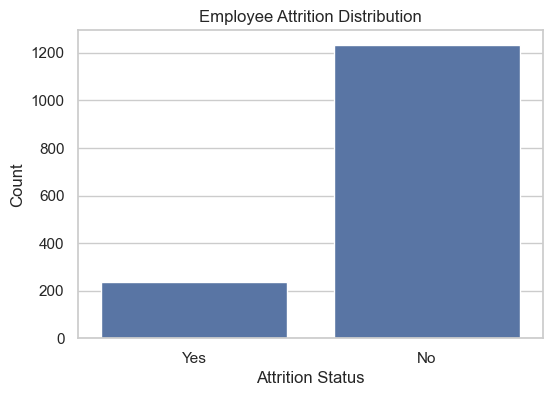

Insight: Overall attrition rate is 16.12% of the workforce.
Insight: This establishes the baseline for all further analysis.

Department Distribution:


Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

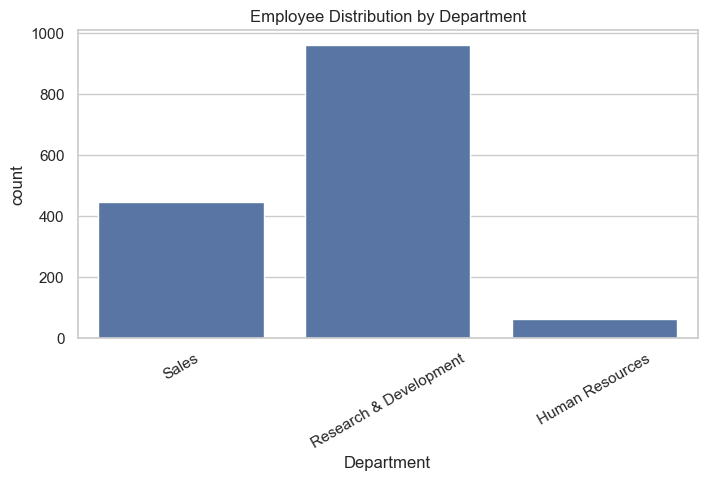

Insight: 'Research & Development' has the highest number of employees.
Insight: 'Human Resources' has the smallest workforce representation.

Job Role Distribution:


JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

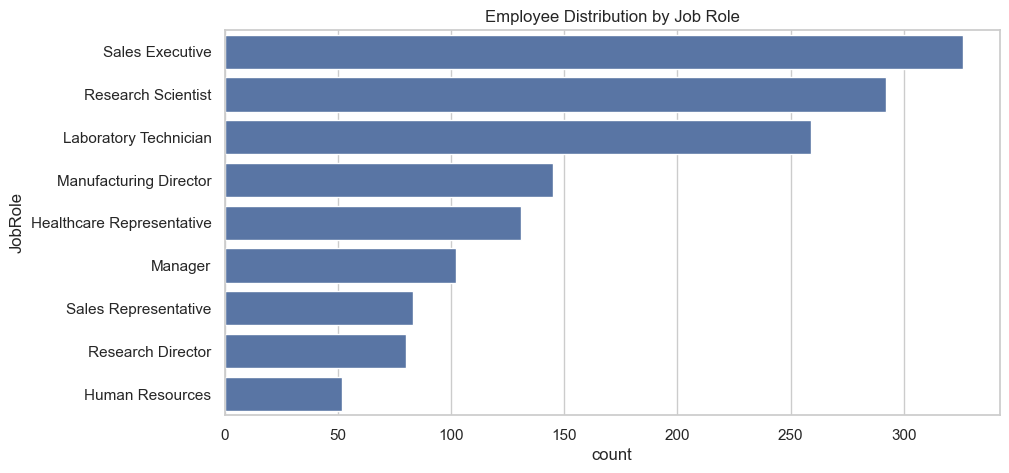

Insight: 'Sales Executive' is the most common job role.
Insight: 'Human Resources' has the lowest representation.

Attrition Rate by Department:


Attrition,No,Yes
Department,,
Human Resources,0.809524,0.190476
Research & Development,0.861602,0.138398
Sales,0.793722,0.206278


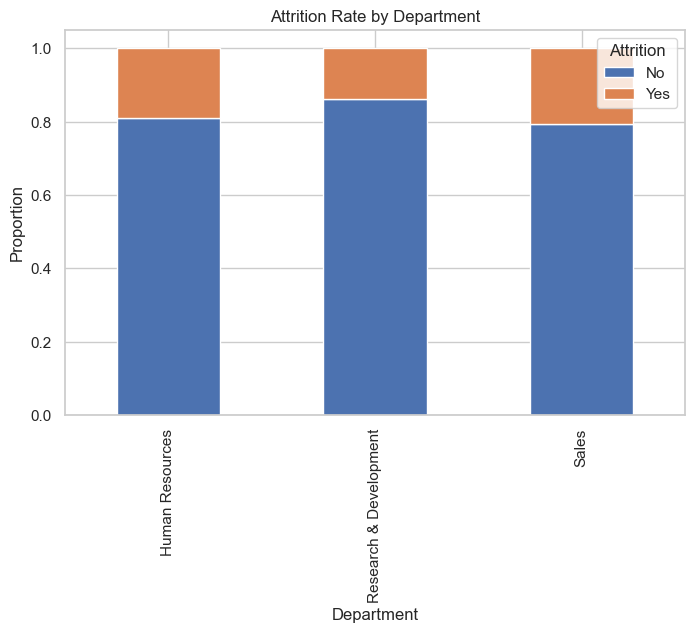

Insight: 'Sales' shows the highest attrition rate.
Insight: 'Research & Development' shows the lowest attrition rate.

Attrition Rate by Job Role:


Attrition,No,Yes
JobRole,,
Healthcare Representative,0.931298,0.068702
Human Resources,0.769231,0.230769
Laboratory Technician,0.760618,0.239382
Manager,0.950980,0.049020
Manufacturing Director,0.931034,0.068966
Research Director,0.975000,0.025000
Research Scientist,0.839041,0.160959
Sales Executive,0.825153,0.174847
Sales Representative,0.602410,0.397590


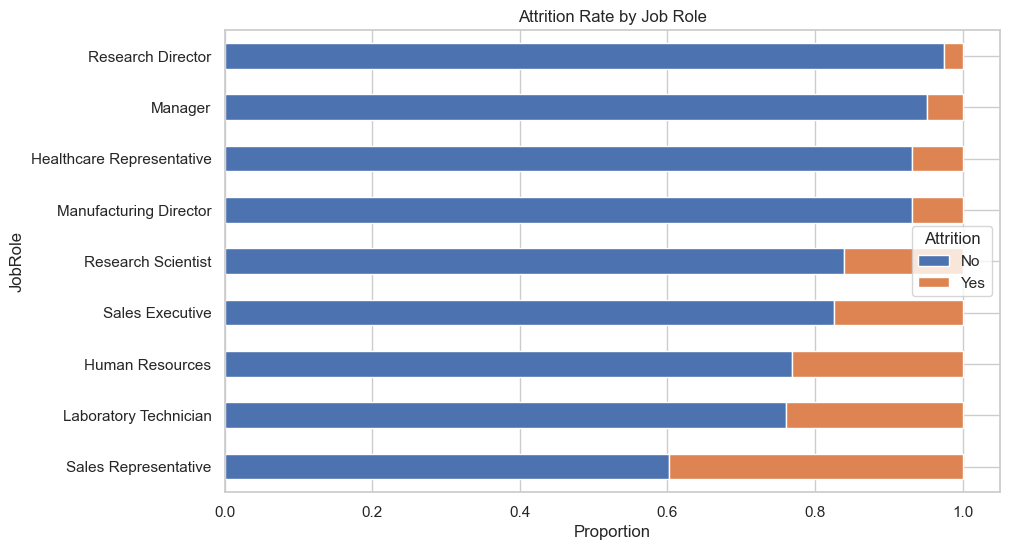

Insight: 'Sales Representative' has the highest attrition rate among roles.
Insight: 'Research Director' has the lowest attrition rate among roles.

Attrition vs OverTime:


Attrition,No,Yes
OverTime,,
No,0.895636,0.104364
Yes,0.694712,0.305288


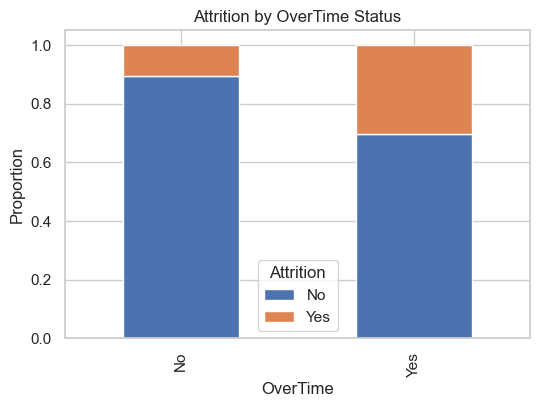

Insight: Employees working overtime have an attrition rate of 30.53%.
Insight: Employees not working overtime have an attrition rate of 10.44%.


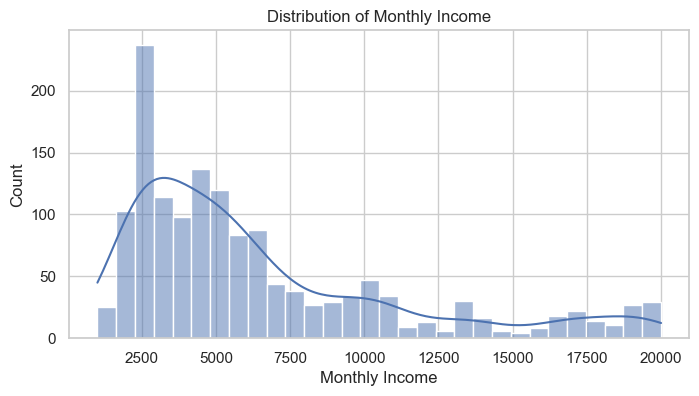

Insight: Average monthly income is 6502.93.
Insight: Median income is 4919.00, indicating distribution skew if different from mean.


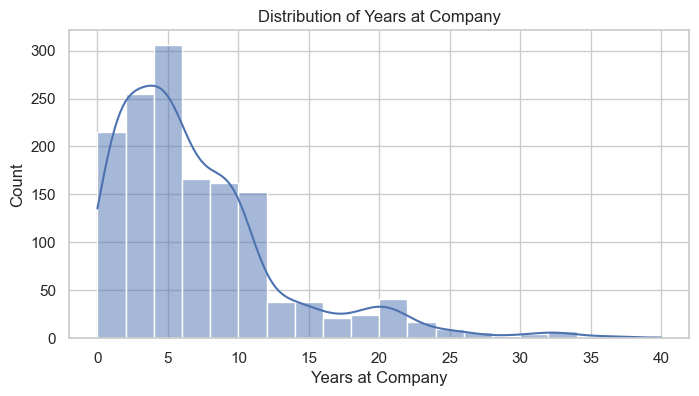

Insight: Average tenure is 7.01 years.
Insight: This helps identify whether the workforce is early-tenure heavy.

Attrition by Years at Company:


Attrition,No,Yes
YearsAtCompany,,
0,0.636364,0.363636
1,0.654971,0.345029
2,0.787402,0.212598
3,0.843750,0.156250
4,0.827273,0.172727
5,0.892857,0.107143
6,0.881579,0.118421
7,0.877778,0.122222
8,0.887500,0.112500


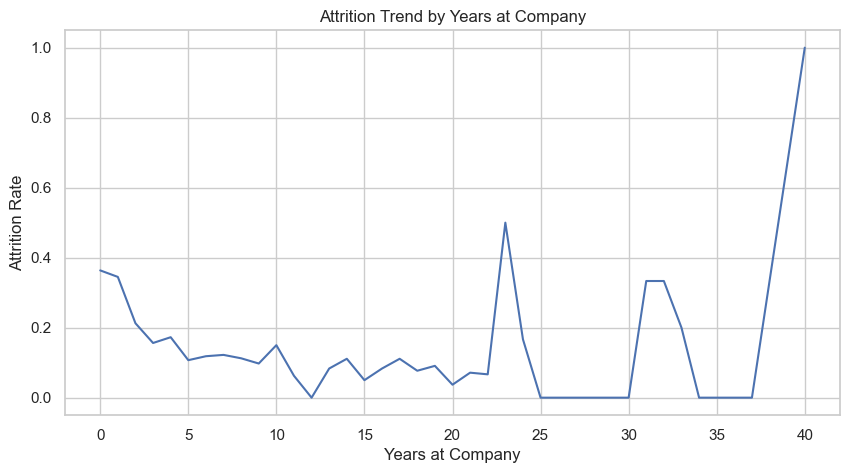

Insight: Attrition peaks around 40 years of tenure.
Insight: This indicates potential early-stage or mid-career disengagement.


In [6]:
# ============================================================
# Objective:
# To explore workforce distribution and identify where attrition
# is concentrated, while automatically extracting key insights
# from each visualization.
# ============================================================


# -------------------------------
# 1. Import Visualization Libraries
# -------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# -------------------------------
# 2. Attrition Distribution
# -------------------------------

print("\nAttrition Distribution:")
attrition_counts = df['Attrition'].value_counts()
display(attrition_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition Status")
plt.ylabel("Count")
plt.show()

# Insight extraction
total_employees = len(df)
attrition_rate = attrition_counts['Yes'] / total_employees

print(f"Insight: Overall attrition rate is {attrition_rate:.2%} of the workforce.")
print("Insight: This establishes the baseline for all further analysis.")


# -------------------------------
# 3. Department Distribution
# -------------------------------

print("\nDepartment Distribution:")
dept_counts = df['Department'].value_counts()
display(dept_counts)

plt.figure(figsize=(8,4))
sns.countplot(x='Department', data=df)
plt.title("Employee Distribution by Department")
plt.xticks(rotation=30)
plt.show()

# Insight extraction
largest_dept = dept_counts.idxmax()
smallest_dept = dept_counts.idxmin()

print(f"Insight: '{largest_dept}' has the highest number of employees.")
print(f"Insight: '{smallest_dept}' has the smallest workforce representation.")


# -------------------------------
# 4. Job Role Distribution
# -------------------------------

print("\nJob Role Distribution:")
role_counts = df['JobRole'].value_counts()
display(role_counts)

plt.figure(figsize=(10,5))
sns.countplot(y='JobRole', data=df, order=role_counts.index)
plt.title("Employee Distribution by Job Role")
plt.show()

# Insight extraction
top_role = role_counts.idxmax()
bottom_role = role_counts.idxmin()

print(f"Insight: '{top_role}' is the most common job role.")
print(f"Insight: '{bottom_role}' has the lowest representation.")


# -------------------------------
# 5. Attrition by Department
# -------------------------------

dept_attrition = pd.crosstab(df['Department'], df['Attrition'], normalize='index')

print("\nAttrition Rate by Department:")
display(dept_attrition)

dept_attrition.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Attrition Rate by Department")
plt.ylabel("Proportion")
plt.show()

# Insight extraction
highest_dept_attr = dept_attrition['Yes'].idxmax()
lowest_dept_attr = dept_attrition['Yes'].idxmin()

print(f"Insight: '{highest_dept_attr}' shows the highest attrition rate.")
print(f"Insight: '{lowest_dept_attr}' shows the lowest attrition rate.")


# -------------------------------
# 6. Attrition by Job Role
# -------------------------------

role_attrition = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index')

print("\nAttrition Rate by Job Role:")
display(role_attrition)

role_attrition.sort_values(by='Yes', ascending=False).plot(
    kind='barh', stacked=True, figsize=(10,6)
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Proportion")
plt.show()

# Insight extraction
highest_role_attr = role_attrition['Yes'].idxmax()
lowest_role_attr = role_attrition['Yes'].idxmin()

print(f"Insight: '{highest_role_attr}' has the highest attrition rate among roles.")
print(f"Insight: '{lowest_role_attr}' has the lowest attrition rate among roles.")


# -------------------------------
# 7. OverTime vs Attrition
# -------------------------------

overtime_attrition = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')

print("\nAttrition vs OverTime:")
display(overtime_attrition)

overtime_attrition.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title("Attrition by OverTime Status")
plt.ylabel("Proportion")
plt.show()

# Insight extraction
high_ot_attr = overtime_attrition.loc['Yes', 'Yes']
low_ot_attr = overtime_attrition.loc['No', 'Yes']

print(f"Insight: Employees working overtime have an attrition rate of {high_ot_attr:.2%}.")
print(f"Insight: Employees not working overtime have an attrition rate of {low_ot_attr:.2%}.")


# -------------------------------
# 8. Monthly Income Distribution
# -------------------------------

plt.figure(figsize=(8,4))
sns.histplot(df['MonthlyIncome'], bins=30, kde=True)
plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income")
plt.show()

# Insight extraction
mean_income = df['MonthlyIncome'].mean()
median_income = df['MonthlyIncome'].median()

print(f"Insight: Average monthly income is {mean_income:.2f}.")
print(f"Insight: Median income is {median_income:.2f}, indicating distribution skew if different from mean.")


# -------------------------------
# 9. Years at Company Distribution
# -------------------------------

plt.figure(figsize=(8,4))
sns.histplot(df['YearsAtCompany'], bins=20, kde=True)
plt.title("Distribution of Years at Company")
plt.xlabel("Years at Company")
plt.show()

# Insight extraction
avg_tenure = df['YearsAtCompany'].mean()

print(f"Insight: Average tenure is {avg_tenure:.2f} years.")
print("Insight: This helps identify whether the workforce is early-tenure heavy.")


# -------------------------------
# 10. Attrition by Tenure
# -------------------------------

tenure_attrition = pd.crosstab(df['YearsAtCompany'], df['Attrition'], normalize='index')

print("\nAttrition by Years at Company:")
display(tenure_attrition.head(10))

tenure_attrition['Yes'].plot(figsize=(10,5))
plt.title("Attrition Trend by Years at Company")
plt.ylabel("Attrition Rate")
plt.xlabel("Years at Company")
plt.show()

# Insight extraction
peak_attrition_year = tenure_attrition['Yes'].idxmax()

print(f"Insight: Attrition peaks around {peak_attrition_year} years of tenure.")
print("Insight: This indicates potential early-stage or mid-career disengagement.")


# ============================================================
# END OF STEP 2
# This step identifies where attrition exists and highlights
# key workforce distribution patterns with clear insights.
# ============================================================

STEP 3: BEHAVIORAL & SATISFACTION ANALYSIS (WITH INSIGHTS)


Attrition Rate by Job Satisfaction:


Attrition,No,Yes
JobSatisfaction_Label,,
High,0.834842,0.165158
Low,0.771626,0.228374
Medium,0.835714,0.164286
Very High,0.886710,0.113290


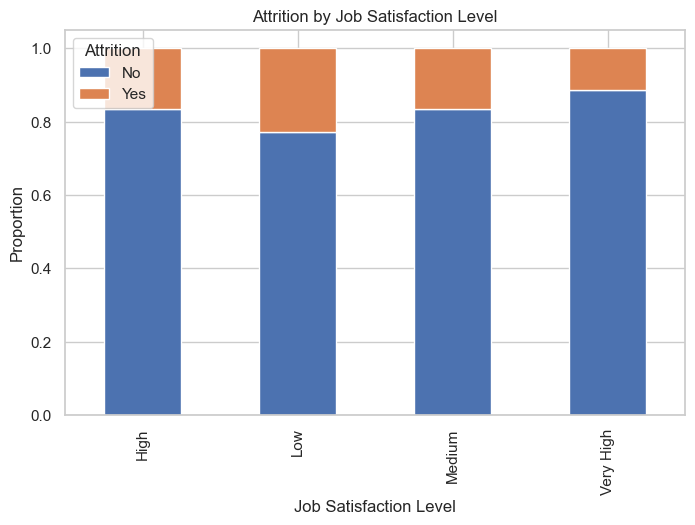

Insight: Employees with 'Low' job satisfaction show the highest attrition rate.
Insight: Employees with 'Very High' job satisfaction show the lowest attrition rate.

Attrition Rate by Work-Life Balance:


Attrition,No,Yes
WorkLifeBalance_Label,,
Bad,0.687500,0.312500
Best,0.823529,0.176471
Better,0.857783,0.142217
Good,0.831395,0.168605


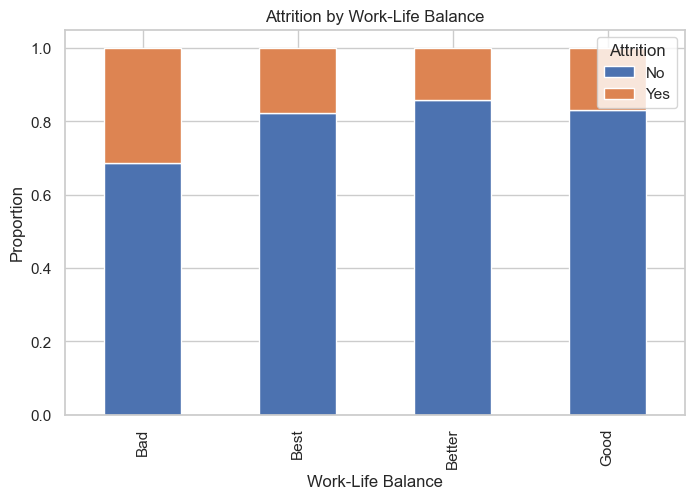

Insight: Attrition is highest among employees with 'Bad' work-life balance.

Attrition Rate by Environment Satisfaction:


Attrition,No,Yes
EnvironmentSatisfaction_Label,,
High,0.863135,0.136865
Low,0.746479,0.253521
Medium,0.850174,0.149826
Very High,0.865471,0.134529


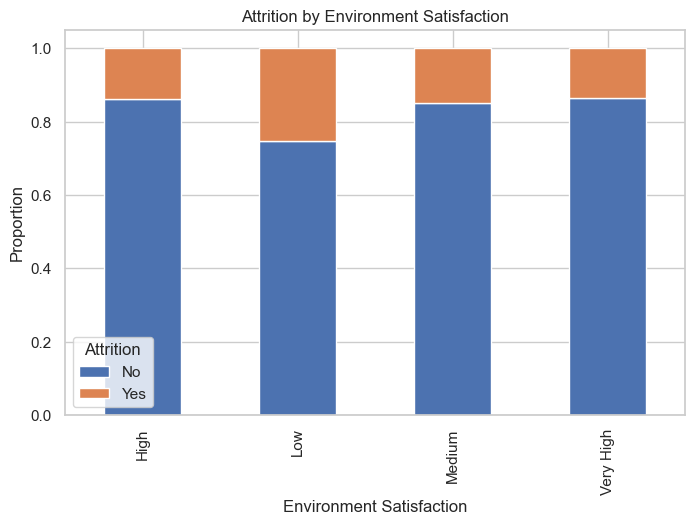

Insight: Employees with 'Low' environment satisfaction show the highest attrition.

Attrition Rate by Relationship Satisfaction:


Attrition,No,Yes
RelationshipSatisfaction_Label,,
High,0.845316,0.154684
Low,0.793478,0.206522
Medium,0.851485,0.148515
Very High,0.851852,0.148148


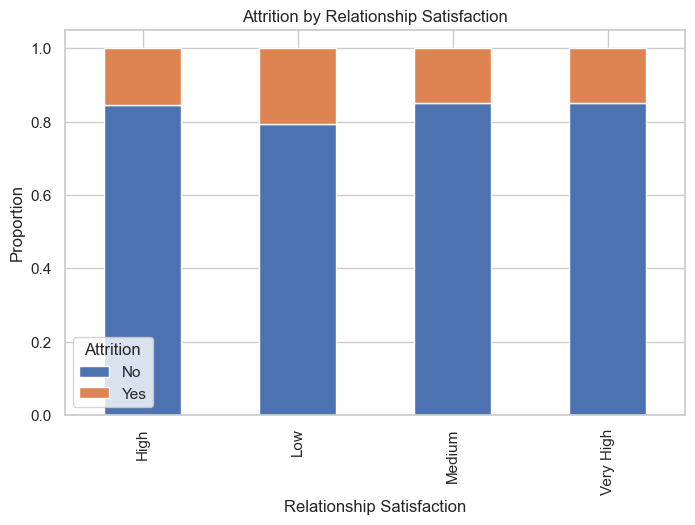

Insight: Attrition is highest among employees with 'Low' relationship satisfaction.

Attrition Rate by Job Involvement:


Attrition,No,Yes
JobInvolvement_Label,,
High,0.855991,0.144009
Low,0.662651,0.337349
Medium,0.810667,0.189333
Very High,0.909722,0.090278


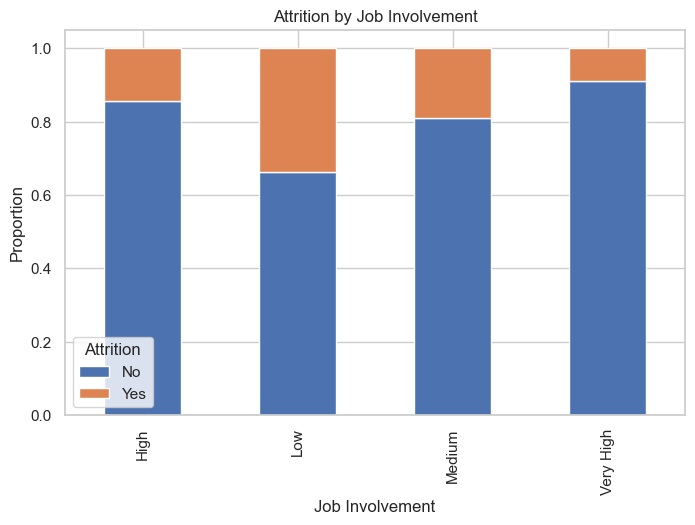

Insight: Employees with 'Low' job involvement show the highest attrition.

Combined Effect: Job Satisfaction + Work-Life Balance:


Attrition                                          No       Yes
JobSatisfaction_Label WorkLifeBalance_Label                    
Low                   Bad                    0.529412  0.470588
High                  Bad                    0.619048  0.380952
Medium                Best                   0.724138  0.275862
                      Bad                    0.777778  0.222222
Low                   Better                 0.785714  0.214286
                      Good                   0.786885  0.213115
Very High             Bad                    0.791667  0.208333
Low                   Best                   0.793103  0.206897
Very High             Best                   0.812500  0.187500
High                  Good                   0.821782  0.178218

Insight: The combination ('Low', 'Bad') has the highest attrition risk.

Job Involvement vs Performance Rating:


PerformanceRating,3,4
JobInvolvement_Label,,
High,0.849078,0.150922
Low,0.795181,0.204819
Medium,0.845333,0.154667
Very High,0.861111,0.138889


Insight: This table helps evaluate whether high performance aligns with higher involvement levels.

Attrition by Satisfaction Index:


Attrition,No,Yes
SatisfactionCategory,,
Low,0.778612,0.221388
Medium,0.865832,0.134168
High,0.883598,0.116402


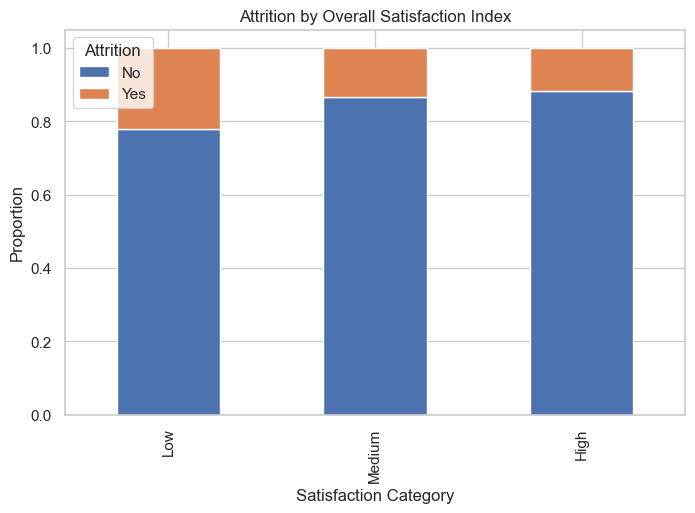

Insight: Employees in the 'Low' satisfaction category show the highest attrition.

OverTime + Job Satisfaction vs Attrition:


Attrition                             No       Yes
OverTime JobSatisfaction_Label                    
Yes      Medium                 0.623188  0.376812
         Low                    0.642857  0.357143
         High                   0.661157  0.338843
         Very High              0.788732  0.211268
No       Low                    0.824390  0.175610
         High                   0.900312  0.099688
         Medium                 0.905213  0.094787
         Very High              0.930599  0.069401

Insight: Employees with combination ('Yes', 'Medium') have the highest attrition risk.


In [7]:
# ============================================================
# Objective:
# To analyze how satisfaction and behavioral factors influence attrition
# and automatically extract meaningful insights alongside visualizations.
# ============================================================


# -------------------------------
# 1. Attrition vs Job Satisfaction
# -------------------------------

job_sat_attrition = pd.crosstab(df['JobSatisfaction_Label'], df['Attrition'], normalize='index')

print("\nAttrition Rate by Job Satisfaction:")
display(job_sat_attrition)

job_sat_attrition.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Attrition by Job Satisfaction Level")
plt.ylabel("Proportion")
plt.xlabel("Job Satisfaction Level")
plt.show()

# Insight extraction
highest_attrition = job_sat_attrition['Yes'].idxmax()
lowest_attrition = job_sat_attrition['Yes'].idxmin()

print(f"Insight: Employees with '{highest_attrition}' job satisfaction show the highest attrition rate.")
print(f"Insight: Employees with '{lowest_attrition}' job satisfaction show the lowest attrition rate.")


# -------------------------------
# 2. Attrition vs Work-Life Balance
# -------------------------------

wlb_attrition = pd.crosstab(df['WorkLifeBalance_Label'], df['Attrition'], normalize='index')

print("\nAttrition Rate by Work-Life Balance:")
display(wlb_attrition)

wlb_attrition.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Attrition by Work-Life Balance")
plt.ylabel("Proportion")
plt.xlabel("Work-Life Balance")
plt.show()

# Insight extraction
highest_wlb = wlb_attrition['Yes'].idxmax()
print(f"Insight: Attrition is highest among employees with '{highest_wlb}' work-life balance.")


# -------------------------------
# 3. Attrition vs Environment Satisfaction
# -------------------------------

env_attrition = pd.crosstab(df['EnvironmentSatisfaction_Label'], df['Attrition'], normalize='index')

print("\nAttrition Rate by Environment Satisfaction:")
display(env_attrition)

env_attrition.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Attrition by Environment Satisfaction")
plt.ylabel("Proportion")
plt.xlabel("Environment Satisfaction")
plt.show()

# Insight extraction
highest_env = env_attrition['Yes'].idxmax()
print(f"Insight: Employees with '{highest_env}' environment satisfaction show the highest attrition.")


# -------------------------------
# 4. Attrition vs Relationship Satisfaction
# -------------------------------

rel_attrition = pd.crosstab(df['RelationshipSatisfaction_Label'], df['Attrition'], normalize='index')

print("\nAttrition Rate by Relationship Satisfaction:")
display(rel_attrition)

rel_attrition.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Attrition by Relationship Satisfaction")
plt.ylabel("Proportion")
plt.xlabel("Relationship Satisfaction")
plt.show()

# Insight extraction
highest_rel = rel_attrition['Yes'].idxmax()
print(f"Insight: Attrition is highest among employees with '{highest_rel}' relationship satisfaction.")


# -------------------------------
# 5. Attrition vs Job Involvement
# -------------------------------

inv_attrition = pd.crosstab(df['JobInvolvement_Label'], df['Attrition'], normalize='index')

print("\nAttrition Rate by Job Involvement:")
display(inv_attrition)

inv_attrition.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Attrition by Job Involvement")
plt.ylabel("Proportion")
plt.xlabel("Job Involvement")
plt.show()

# Insight extraction
highest_inv = inv_attrition['Yes'].idxmax()
print(f"Insight: Employees with '{highest_inv}' job involvement show the highest attrition.")


# -------------------------------
# 6. Multi-Factor Analysis:
# Job Satisfaction + Work-Life Balance
# -------------------------------

multi_attrition = pd.crosstab(
    [df['JobSatisfaction_Label'], df['WorkLifeBalance_Label']],
    df['Attrition'],
    normalize='index'
)

print("\nCombined Effect: Job Satisfaction + Work-Life Balance:")
display(multi_attrition.sort_values(by='Yes', ascending=False).head(10))

# Insight extraction
top_combination = multi_attrition['Yes'].idxmax()
print(f"Insight: The combination {top_combination} has the highest attrition risk.")


# -------------------------------
# 7. Job Involvement vs Performance Rating
# -------------------------------

perf_involvement = pd.crosstab(
    df['JobInvolvement_Label'],
    df['PerformanceRating'],
    normalize='index'
)

print("\nJob Involvement vs Performance Rating:")
display(perf_involvement)

# Insight extraction
print("Insight: This table helps evaluate whether high performance aligns with higher involvement levels.")


# -------------------------------
# 8. Satisfaction Index
# -------------------------------

df['SatisfactionIndex'] = (
    df['JobSatisfaction'] +
    df['EnvironmentSatisfaction'] +
    df['RelationshipSatisfaction']
) / 3

df['SatisfactionCategory'] = pd.qcut(
    df['SatisfactionIndex'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

sat_index_attrition = pd.crosstab(
    df['SatisfactionCategory'],
    df['Attrition'],
    normalize='index'
)

print("\nAttrition by Satisfaction Index:")
display(sat_index_attrition)

sat_index_attrition.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Attrition by Overall Satisfaction Index")
plt.ylabel("Proportion")
plt.xlabel("Satisfaction Category")
plt.show()

# Insight extraction
highest_sat = sat_index_attrition['Yes'].idxmax()
print(f"Insight: Employees in the '{highest_sat}' satisfaction category show the highest attrition.")


# -------------------------------
# 9. OverTime + Job Satisfaction
# -------------------------------

overtime_multi = pd.crosstab(
    [df['OverTime'], df['JobSatisfaction_Label']],
    df['Attrition'],
    normalize='index'
)

print("\nOverTime + Job Satisfaction vs Attrition:")
display(overtime_multi.sort_values(by='Yes', ascending=False).head(10))

# Insight extraction
top_overtime = overtime_multi['Yes'].idxmax()
print(f"Insight: Employees with combination {top_overtime} have the highest attrition risk.")


# ============================================================
# END OF STEP 3
# This step combines visual analysis with direct insight extraction,
# making findings more actionable and easier to interpret.
# ============================================================

STEP 4: CORRELATION + FEATURE IMPORTANCE + RISK SEGMENTATION


Correlation Matrix (Top Relationships with Attrition):


Attrition_Flag              1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
SatisfactionIndex          -0.146819
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
EmployeeCount                    NaN
S

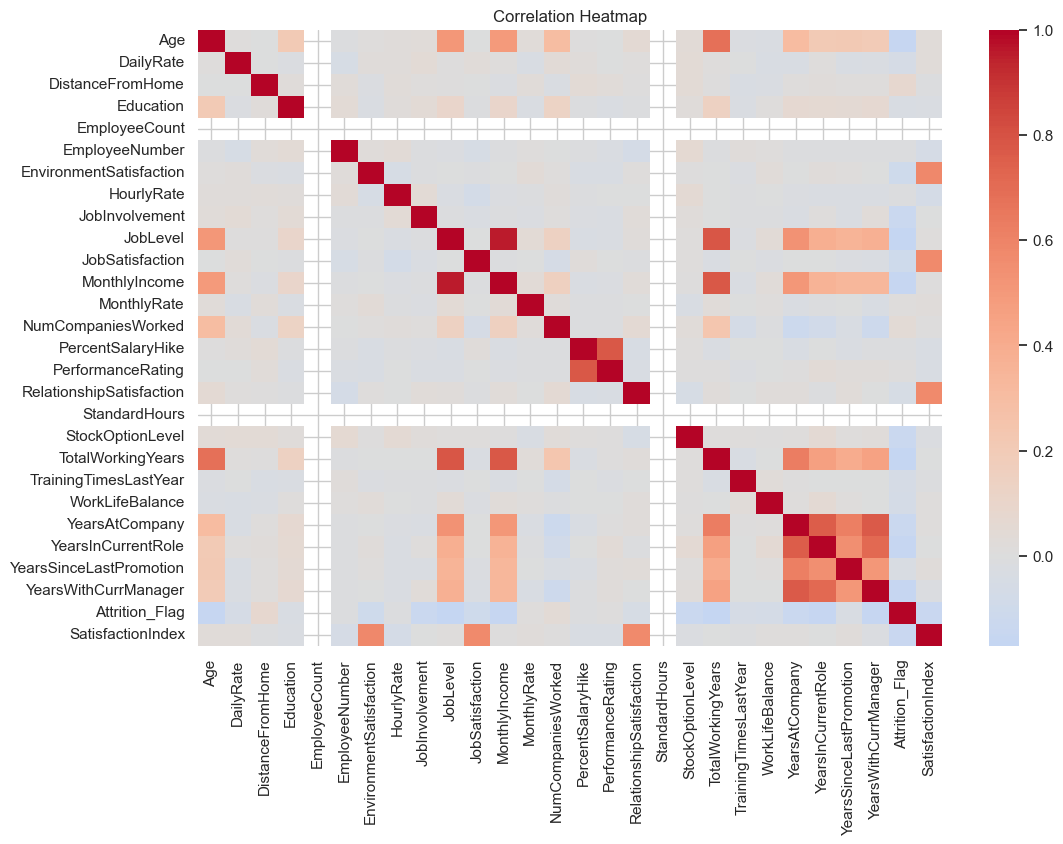

Insight: 'DistanceFromHome' shows the strongest positive correlation with attrition.
Insight: 'StandardHours' shows the strongest negative correlation with attrition.

Feature Importance (Logistic Regression):


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


JobSatisfaction_Label_Low            0.175674
BusinessTravel_Travel_Frequently     0.182634
EnvironmentSatisfaction_Label_Low    0.183003
Department_Sales                     0.202316
NumCompaniesWorked                   0.265202
YearsAtCompany                       0.296255
YearsSinceLastPromotion              0.360876
MaritalStatus_Single                 0.381940
OverTime_Yes                         0.636106
Attrition_Yes                        1.832162
dtype: float64

Insight: 'Attrition_Yes' is the strongest driver increasing attrition risk.
Insight: 'StockOptionLevel' contributes most toward employee retention.

Attrition by Risk Level:


Attrition,No,Yes
RiskLevel,,
High Risk,0.589744,0.410256
Low Risk,0.861265,0.138735
Medium Risk,0.818868,0.181132


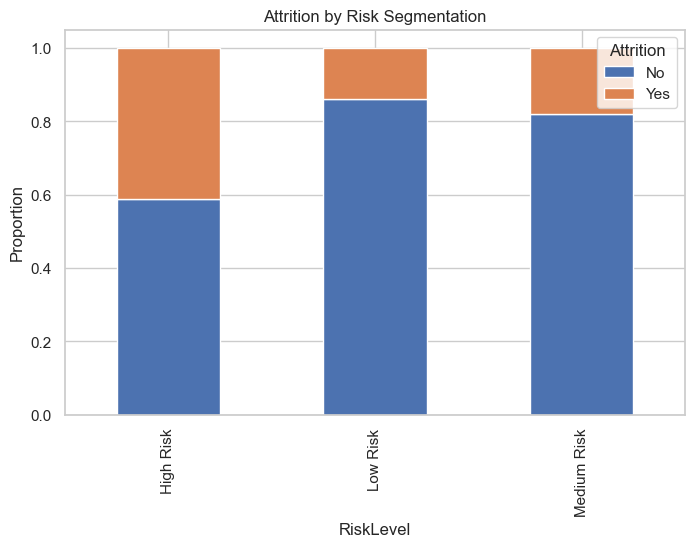

Insight: 'High Risk' category has the highest attrition rate.
Insight: Risk segmentation helps identify employees who need immediate intervention.

Risk Category Distribution:


RiskLevel
Low Risk       901
Medium Risk    530
High Risk       39
Name: count, dtype: int64

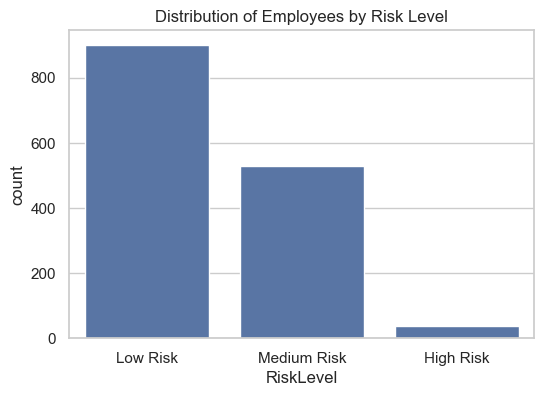

Insight: Majority of employees fall under 'Low Risk' category.
Insight: This helps estimate the proportion of workforce at risk.

Risk Distribution by Department:


RiskLevel,High Risk,Low Risk,Medium Risk
Department,,,
Human Resources,0.000000,0.507937,0.492063
Research & Development,0.027055,0.619147,0.353798
Sales,0.029148,0.614350,0.356502


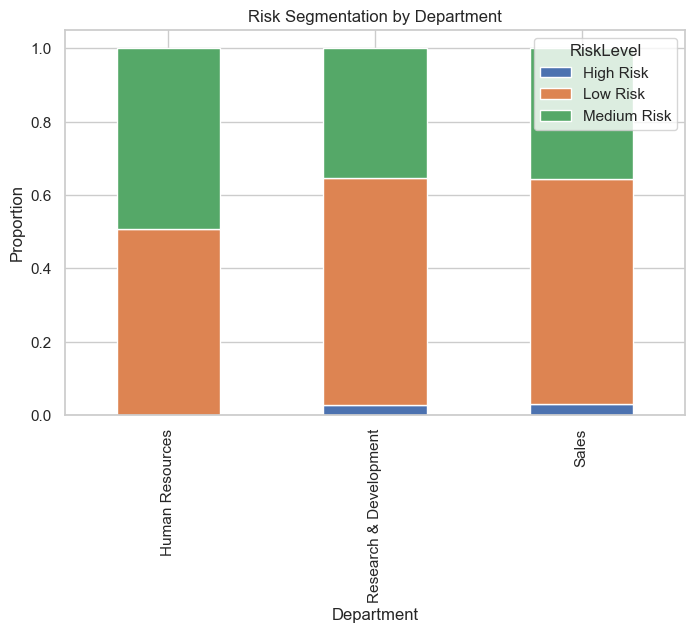

Insight: This helps identify which departments have higher concentrations of high-risk employees.


In [8]:
# ============================================================
# Objective:
# To quantify relationships between variables, identify key drivers
# of attrition, and segment employees into risk categories.
# ============================================================


# -------------------------------
# 1. Prepare Data for Correlation
# -------------------------------

# Convert Attrition into numeric format for correlation analysis
df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])


# -------------------------------
# 2. Correlation Analysis
# -------------------------------

correlation_matrix = numeric_df.corr()

print("\nCorrelation Matrix (Top Relationships with Attrition):")
attrition_corr = correlation_matrix['Attrition_Flag'].sort_values(ascending=False)
display(attrition_corr)

# Visualization: Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

# Insight extraction
top_positive = attrition_corr.index[1]
top_negative = attrition_corr.index[-1]

print(f"Insight: '{top_positive}' shows the strongest positive correlation with attrition.")
print(f"Insight: '{top_negative}' shows the strongest negative correlation with attrition.")


# -------------------------------
# 3. Feature Importance using Logistic Regression
# -------------------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Encoding categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Attrition_Flag', axis=1)
y = df_encoded['Attrition_Flag']

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Model training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Extract feature importance
feature_importance = pd.Series(model.coef_[0], index=X.columns).sort_values()

print("\nFeature Importance (Logistic Regression):")
display(feature_importance.tail(10))

# Insight extraction
top_driver = feature_importance.idxmax()
least_driver = feature_importance.idxmin()

print(f"Insight: '{top_driver}' is the strongest driver increasing attrition risk.")
print(f"Insight: '{least_driver}' contributes most toward employee retention.")


# -------------------------------
# 4. Risk Segmentation (Rule-Based)
# -------------------------------

def risk_category(row):
    if (row['JobSatisfaction'] <= 2 and 
        row['WorkLifeBalance'] <= 2 and 
        row['OverTime'] == 'Yes'):
        return 'High Risk'
    elif (row['JobSatisfaction'] <= 2):
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['RiskLevel'] = df.apply(risk_category, axis=1)

risk_distribution = pd.crosstab(df['RiskLevel'], df['Attrition'], normalize='index')

print("\nAttrition by Risk Level:")
display(risk_distribution)

risk_distribution.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Attrition by Risk Segmentation")
plt.ylabel("Proportion")
plt.show()

# Insight extraction
highest_risk = risk_distribution['Yes'].idxmax()

print(f"Insight: '{highest_risk}' category has the highest attrition rate.")
print("Insight: Risk segmentation helps identify employees who need immediate intervention.")


# -------------------------------
# 5. Risk Distribution Across Workforce
# -------------------------------

risk_counts = df['RiskLevel'].value_counts()

print("\nRisk Category Distribution:")
display(risk_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='RiskLevel', data=df, order=risk_counts.index)
plt.title("Distribution of Employees by Risk Level")
plt.show()

# Insight extraction
dominant_risk = risk_counts.idxmax()

print(f"Insight: Majority of employees fall under '{dominant_risk}' category.")
print("Insight: This helps estimate the proportion of workforce at risk.")


# -------------------------------
# 6. High-Risk Segments by Department
# -------------------------------

dept_risk = pd.crosstab(df['Department'], df['RiskLevel'], normalize='index')

print("\nRisk Distribution by Department:")
display(dept_risk)

dept_risk.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Risk Segmentation by Department")
plt.ylabel("Proportion")
plt.show()

# Insight extraction
print("Insight: This helps identify which departments have higher concentrations of high-risk employees.")


# ============================================================
# END OF STEP 4
# This step quantifies drivers of attrition and segments employees
# into actionable risk categories for strategic decision-making.
# ============================================================

STEP 5: EXPORT CLEANED DATA FOR POWER BI

In [10]:
# ============================================================
# This step saves the cleaned and transformed dataset as a CSV file.
# The exported file will be used as the data source for Power BI.

# Exporting dataset
df.to_csv("cleaned_hr_data.csv", index=False)

# Confirming successful export
print("Cleaned dataset has been successfully saved as 'cleaned_hr_data.csv'.")

# Additional note:
# - The file is saved in the current working directory.
# - This dataset includes engineered features such as:
#   • SatisfactionIndex
#   • SatisfactionCategory
#   • RiskLevel
#   • Attrition_Flag
# - These features enhance analytical capabilities in Power BI.

Cleaned dataset has been successfully saved as 'cleaned_hr_data.csv'.
